In [1]:
import torch
import torchvision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

In [2]:
path = kagglehub.dataset_download("waalbannyantudre/hate-speech-detection-curated-dataset")

100%|██████████| 114M/114M [00:06<00:00, 17.9MB/s]

Extracting files...


In [3]:
print(path)

/root/.cache/kagglehub/datasets/waalbannyantudre/hate-speech-detection-curated-dataset/versions/1


In [4]:
import os
hate_speech_data = pd.read_csv(os.path.join(path, "HateSpeechDatasetBalanced.csv"))
print(hate_speech_data.head())
print(hate_speech_data['Label'].value_counts())

                                             Content  Label
0  denial of normal the con be asked to comment o...      1
1  just by being able to tweet this insufferable ...      1
2  that is retarded you too cute to be single tha...      1
3  thought of a real badass mongol style declarat...      1
4                                afro american basho      1
Label
1    364525
0    361594
Name: count, dtype: int64


In [5]:
!pip install transformers contractions emoji torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00


In [6]:
import nltk, spacy, re, string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer, WordNetLemmatizer
import contractions
import emoji

nltk.download(['punkt_tab', 'wordnet', 'punkt', 'stopwords', 'averaged_perceptron_tagger'], quiet=True)

stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

punctuation_pattern = re.compile(f"[{re.escape(string.punctuation)}]")
digit_pattern = re.compile(r'\d+')
whitespace_pattern = re.compile(r'\s+')
non_word_pattern = re.compile(r'\W+')

def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()
    text = contractions.fix(text)
    text = digit_pattern.sub(' ', text)
    text = punctuation_pattern.sub(' ', text)
    text = non_word_pattern.sub(' ', text)
    text = whitespace_pattern.sub(' ', text).strip()
    text = emoji.demojize(text)
    return text

hate_speech_data['Cleaned_Content'] = hate_speech_data['Content'].apply(clean_text)

In [7]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(hate_speech_data, test_size=0.2, random_state=42, shuffle=True, stratify=hate_speech_data['Label'])

In [8]:
len(train_data), len(test_data)

(580895, 145224)

In [9]:
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertModel, DistilBertTokenizer

from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding


class HateSpeechDataset(Dataset):

    def __init__(self, tokenizer, data):
        self.tokenizer = tokenizer
        self.data = data


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        text = item['Cleaned_Content']
        label = item['Label']
        encoding = self.tokenizer.encode_plus(text, padding='max_length', truncation=True, max_length=64, return_tensors='pt')
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"],
            "labels": label,
            "text": text
        }


In [10]:

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Define Classifier model

In [11]:
class HateSpeechClassifier(nn.Module):
    def __init__(self, unfreeze_layers=5, dropout=0.4):
        super(HateSpeechClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        for n, p in self.bert.named_parameters():
            p.requires_grad = False
        for param in self.bert.embeddings.parameters():
                param.requires_grad = True
        for layer in self.bert.transformer.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True
        self.pooling_dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout*0.7),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout*0.5),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask):
        last_hidden = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        last_hidden = self.pooling_dropout(last_hidden)
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        pooled = sum_embeddings / sum_mask
        # cls_embedding = outputs[:, 0, :]
        output = self.classifier(pooled)
        return output

In [12]:
train_dataset = HateSpeechDataset(tokenizer=tokenizer, data=train_data)
test_dataset = HateSpeechDataset(tokenizer=tokenizer, data=test_data)

from transformers import DataCollatorWithPadding, get_linear_schedule_with_warmup

# collator = DataCollatorWithPadding(tokenizer=tokenizer)

def collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch]),
        'text': [x['text'] for x in batch]
    }

batch_size = 64
num_epochs = 3
dataloader_train = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=2,
                              collate_fn=collate_fn,
                              pin_memory=True)

dataloader_test = DataLoader(test_dataset,
                             batch_size=batch_size,
                             shuffle=False,
                             num_workers=2,
                             collate_fn=collate_fn,
                             pin_memory=True)
model = HateSpeechClassifier()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_training_steps = len(dataloader_train) * num_epochs
num_warmup_steps = int(0.1 * num_training_steps)
optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 4e-4}
], weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

loss_fn = nn.BCEWithLogitsLoss()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [13]:
for i, batch in enumerate(dataloader_train):
    print(batch['input_ids'])
    break

tensor([[  101,  4067,  2017,  ...,     0,     0,     0],
        [  101,  2065,  2017,  ...,     0,     0,     0],
        [  101,  1037,  2304,  ...,     0,     0,     0],
        ...,
        [  101, 11265, 17643,  ...,     0,     0,     0],
        [  101,  3649,  1041,  ...,     0,     0,     0],
        [  101,  2402, 12010,  ...,     0,     0,     0]])


In [14]:
from tqdm import tqdm
import torchmetrics

f1_metric = torchmetrics.F1Score(task="binary").to(device)
precision_metric = torchmetrics.Precision(task="binary").to(device)
recall_metric = torchmetrics.Recall(task="binary").to(device)

misclassified_samples = []
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
train_f1_scores = []
test_f1_scores = []
count_train = 0
count_test = 0
for epoch in range(num_epochs):
    print(f"epoch {epoch+1}/{num_epochs}")
    model.train()
    correct_train = 0
    total_train = 0
    total_train_loss = 0

    f1_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    for i, batch in enumerate(tqdm(dataloader_train)):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Squeeze the attention mask to remove the extra dimension if present
        if attention_mask.dim() > 2:
            attention_mask = attention_mask.squeeze(1)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.squeeze(), labels.float())
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()
        # train_losses.append(loss.item())
        preds = (torch.sigmoid(outputs) > 0.5).long()  # threshold at 0.5
        preds = preds.view(-1)
        labels = labels.view(-1)
        f1_metric.update(preds, labels.long())
        precision_metric.update(preds, labels.long())
        recall_metric.update(preds, labels.long())
        correct_train += (preds == labels.long()).sum().item()
        total_train += labels.size(0)
        count_train += 1

    avg_train_loss = total_train_loss / len(dataloader_train)
    train_losses.append(avg_train_loss)

    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    train_f1 = f1_metric.compute()
    train_precision = precision_metric.compute()
    train_recall = recall_metric.compute()
    train_f1_scores.append(train_f1.item())

    model.eval()
    total_test_loss = 0
    correct_test = 0
    total_test = 0
    preds = list()
    truths = list()

    f1_metric.reset()
    precision_metric.reset()
    recall_metric.reset()

    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader_test)):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            texts = batch.get('text', ['N/A'] * len(labels))

            # If attention_mask has more than 2 dimensions, squeeze it
            if attention_mask.dim() > 2:
                attention_mask = attention_mask.squeeze()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.squeeze(), labels.float())
            total_test_loss += loss.item()
            # test_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) > 0.5).long()
            preds = preds.view(-1)
            labels_flat = labels.view(-1).long()

            # Update metrics
            f1_metric.update(preds, labels_flat)
            precision_metric.update(preds, labels_flat)
            recall_metric.update(preds, labels_flat)

            # --- Collect misclassified samples ---
            # Find indices where prediction != label
            incorrect_mask = (preds != labels_flat)
            if incorrect_mask.any():
                # Get data for incorrect predictions
                incorrect_indices = torch.where(incorrect_mask)[0]
                for idx in incorrect_indices:
                    idx = idx.item()
                    misclassified_samples.append({
                        'epoch': epoch + 1,
                        'text': texts[idx] if idx < len(texts) else 'N/A',
                        'predicted': preds[idx].item(),
                        'actual': labels_flat[idx].item(),
                        # Optional: store confidence/probability
                        'probability': torch.sigmoid(outputs.squeeze()[idx]).item()
                    })

            correct_test += (preds == labels.long()).sum().item()
            total_test += labels.size(0)
            count_test += 1

    test_f1 = f1_metric.compute()
    test_precision = precision_metric.compute()
    test_recall = recall_metric.compute()
    test_f1_scores.append(test_f1.item())

    avg_test_loss = total_test_loss / len(dataloader_test)
    test_losses.append(avg_test_loss)
    test_accuracy = correct_test / total_test
    test_accuracies.append(test_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss}, Test Loss: {avg_test_loss}")
    print(f"Train Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")
    print(f"Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}")
    print(f"Train Precision: {train_precision:.4f}, Test Precision: {test_precision:.4f}")
    print(f"Train Recall: {train_recall:.4f}, Test Recall: {test_recall:.4f}")
    print("-" * 60)

epoch 1/3


100%|██████████| 2270/2270 [04:20<00:00,  8.72it/s]


Epoch 1/3, Train Loss: 0.33336387562770814, Test Loss: 0.257736190877822
Train Accuracy: 0.849291179989499, Test Accuracy: 0.8883173580124497
Train F1: 0.8528, Test F1: 0.8903
Train Precision: 0.8367, Test Precision: 0.8781
Train Recall: 0.8695, Test Recall: 0.9029
------------------------------------------------------------
epoch 2/3


100%|██████████| 2270/2270 [04:18<00:00,  8.77it/s]


Epoch 2/3, Train Loss: 0.21773689691339726, Test Loss: 0.23721145579862174
Train Accuracy: 0.908052229748922, Test Accuracy: 0.8991282432655759
Train F1: 0.9093, Test F1: 0.8982
Train Precision: 0.9011, Test Precision: 0.9105
Train Recall: 0.9176, Test Recall: 0.8861
------------------------------------------------------------
epoch 3/3


100%|██████████| 2270/2270 [04:19<00:00,  8.76it/s]

Epoch 3/3, Train Loss: 0.16071684077140766, Test Loss: 0.23959090326490118
Train Accuracy: 0.9338520730941048, Test Accuracy: 0.9026194017517766
Train F1: 0.9344, Test F1: 0.9012
Train Precision: 0.9306, Test Precision: 0.9187
Train Recall: 0.9382, Test Recall: 0.8842
------------------------------------------------------------


In [15]:
if misclassified_samples:
    df_errors = pd.DataFrame(misclassified_samples)
    print(f"\nTotal misclassified samples collected: {len(df_errors)}")
    # Example: Show some common error patterns
    print("\nError analysis (first 10 samples):")
    print(df_errors.head(10))


Total misclassified samples collected: 45010

Error analysis (first 10 samples):
   epoch                                               text  predicted  \
0      1  reversion given that some jolt vandalized the ...          0   
1      1  saw a dead kitten and cracked my phone within ...          1   
2      1  if laughter is the best medicine who is the id...          1   
3      1  catching up on mr did kat really just say them...          1   
4      1  i am going to go ape shit if there is an if china          1   
5      1  never buy from stores that hire minorities ove...          1   
6      1  russia had ivan the terrible fsu has willie th...          1   
7      1  no i will not stop here who is wrong here is y...          0   
8      1  the pretending president says nothing smfh fuc...          0   
9      1                        these people love hairy men          1   

   actual  probability  
0       1     0.004263  
1       0     0.522607  
2       0     0.791957  
3  

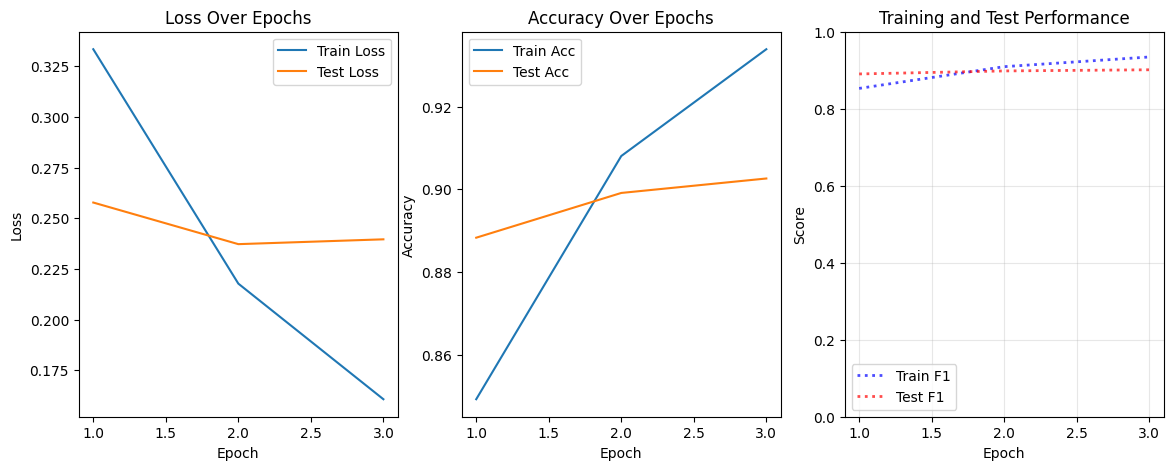

In [16]:

epochs = range(1, num_epochs + 1)
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(14, 5))

# ---------- LOSS ----------
plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

# ---------- ACCURACY ----------
plt.subplot(1, 3, 2)
plt.plot(epochs, train_accuracies, label="Train Acc")
plt.plot(epochs, test_accuracies, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

plt.subplot(1, 3, 3)
# Plot F1 Score
plt.plot(epochs_range, train_f1_scores, 'b:', label='Train F1', linewidth=2, alpha=0.7)
plt.plot(epochs_range, test_f1_scores, 'r:', label='Test F1', linewidth=2, alpha=0.7)

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training and Test Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

In [21]:
torch.save(model.state_dict(), 'hate_speech_model_weights.pth')

## Traditional Transformer method

In [ ]:
from collections import Counter
import re

_basic_english_re = re.compile(r"[^a-zA-Z0-9']+")

def basic_english_tokenizer(text: str):
    """
    A close re-implementation of torchtext's basic_english tokenizer.
    - Lowercases text
    - Removes punctuation except apostrophes
    - Splits on whitespace
    """
    text = text.lower()

    # Replace all non alphanumerics/apostrophes with spaces
    text = _basic_english_re.sub(" ", text)

    # Split on whitespace
    tokens = text.strip().split()

    return tokens

def build_vocab_from_df(df, text_column="Content", min_freq=1):
    counter = Counter()
    for text in df[text_column]:
        tokens = basic_english_tokenizer(text)
        counter.update(tokens)

    vocab = {"<unk>": 0, "<pad>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab_from_df(hate_speech_data, "Content")
tokenizer = basic_english_tokenizer

In [ ]:
def text_pipeline(x):
    tokens = tokenizer(x)
    return [vocab[token] for token in tokens]

def get_text_lengths(data_iter):
    lengths = []
    for _, text in tqdm(data_iter):
        tokenized_text = tokenizer(text)
        lengths.append(len(tokenized_text))
    return np.array(lengths)

def collate_batch(batch, max_seq_len=256):
    labels, texts = zip(*batch)

    labels = torch.tensor(labels, dtype=torch.long) # Removed - 1

    encoded_texts = []
    for text in texts:
        ids = text_pipeline(text)              # token → index list

        if len(ids) > max_seq_len:
            ids = ids[:max_seq_len]
        else:
            pad_id = vocab["<pad>"]
            ids = ids + [pad_id] * (max_seq_len - len(ids))

        encoded_texts.append(torch.tensor(ids))

    encoded_texts = torch.stack(encoded_texts)   # (batch, seq_len)

    return encoded_texts, labels

In [ ]:
class SimpleHateSpeechDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data.iloc[idx]['Label'], self.data.iloc[idx]['Content']

In [ ]:
train_dataset = SimpleHateSpeechDataset(train_data)
test_dataset = SimpleHateSpeechDataset(test_data)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

label_counter = Counter()
for texts, labels in train_loader:
    label_counter.update(labels.tolist())
print("Label counts:", label_counter)

Label counts: Counter({1: 291620, 0: 289275})


In [ ]:
class TransformerModel(torch.nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, num_encoder_layers, num_classes, dropout=0.1):

        super(TransformerModel, self).__init__()

        self.embedding = torch.nn.Embedding(vocab_size, embed_size)
        self.transformer = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(embed_size, num_heads, embed_size * 2, dropout),
            num_encoder_layers
        )
        self.fc = torch.nn.Linear(embed_size, num_classes)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)  # Embedding layer
        x = x.permute(1, 0, 2)  # Transformer expects (seq_len, batch_size, embedding_size)
        x = self.transformer(x)  # Apply transformer
        x = x.mean(dim=0)  # Pooling (take the mean of all tokens in the sequence)
        x = self.dropout(x)
        x = self.fc(x)  # Final classification layer
        return x

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Initialize the model,
embed_size = 128
num_heads = 4
num_encoder_layers = 2
num_classes = 2
model2 = TransformerModel(len(vocab), embed_size, num_heads, num_encoder_layers, num_classes)

# Initialize loss function, and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

model2.to(device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TransformerModel(
  (embedding): Embedding(136964, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [ ]:
num_epochs = 3
train_losses = np.zeros(num_epochs)
train_accuracies = np.zeros(num_epochs)

test_losses = np.zeros(num_epochs)
test_accuracies = np.zeros(num_epochs)

In [ ]:
# YOUR CODE HERE
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    # total_batches = 0
    total_batches = len(train_loader)

    for texts, labels in tqdm(train_loader):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = model(texts)

        # Compute loss and gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Calculate accuracy
        preds = torch.argmax(outputs, dim=1)
        correct = (preds == labels).sum().item()
        accuracy = correct / labels.size(0)

        epoch_loss += loss.item()
        epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches

def evaluate(model, test_loader, loss_fn):
    model.eval()
    epoch_loss = 0
    epoch_accuracy = 0
    total_batches = len(test_loader)
    correct_preds = []
    incorrect_preds = []

    with torch.no_grad():
        for texts, labels in tqdm(test_loader):
            texts, labels = texts.to(device), labels.to(device)
            # Forward pass
            outputs = model(texts)

            # Compute loss
            loss = loss_fn(outputs, labels)

            # Calculate accuracy
            preds = torch.argmax(outputs, dim=1)
            correct_mask = preds == labels
            correct = (preds == labels).sum().item()
            accuracy = correct / labels.size(0)
            for i in range(len(labels)):
                if correct_mask[i]:
                    correct_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    incorrect_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
            epoch_loss += loss.item()
            epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches, correct_preds, incorrect_preds

In [ ]:
# YOUR CODE HERE
def train_epoch(model, train_loader, loss_fn, optimizer):
    model.train()
    epoch_loss = 0
    epoch_accuracy = 0
    # total_batches = 0
    total_batches = len(train_loader)

    for texts, labels in tqdm(train_loader):
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward pass
        outputs = model(texts)

        # Compute loss and gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Calculate accuracy
        preds = torch.argmax(outputs, dim=1)
        correct = (preds == labels).sum().item()
        accuracy = correct / labels.size(0)

        epoch_loss += loss.item()
        epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches

def evaluate(model, test_loader, loss_fn):
    model.eval()
    epoch_loss = 0
    epoch_accuracy = 0
    total_batches = len(test_loader)
    correct_preds = []
    incorrect_preds = []

    with torch.no_grad():
        for texts, labels in tqdm(test_loader):
            texts, labels = texts.to(device), labels.to(device)
            # Forward pass
            outputs = model(texts)

            # Compute loss
            loss = loss_fn(outputs, labels)

            # Calculate accuracy
            preds = torch.argmax(outputs, dim=1)
            correct_mask = preds == labels
            correct = (preds == labels).sum().item()
            accuracy = correct / labels.size(0)
            for i in range(len(labels)):
                if correct_mask[i]:
                    correct_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
                else:
                    incorrect_preds.append((texts[i].cpu(), labels[i].cpu(), preds[i].cpu()))
            epoch_loss += loss.item()
            epoch_accuracy += accuracy

    return epoch_loss / total_batches, epoch_accuracy / total_batches, correct_preds, incorrect_preds

In [ ]:
corr_preds_epochs = []
incorr_preds_epochs = []
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model2, train_loader, loss_fn, optimizer)
    train_losses[epoch] = train_loss
    train_accuracies[epoch] = train_acc

    test_loss, test_acc, correct_preds, incorrect_preds = evaluate(model2, test_loader, loss_fn)
    corr_preds_epochs.append(correct_preds)
    incorr_preds_epochs.append(incorrect_preds)
    test_losses[epoch] = test_loss
    test_accuracies[epoch] = test_acc

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

100%|██████████| 4539/4539 [00:56<00:00, 79.84it/s]


Epoch [1/3]
Train Loss: 0.4166, Train Acc: 0.8064
Test Loss: 0.3825, Test Acc: 0.8305


100%|██████████| 4539/4539 [00:56<00:00, 80.25it/s]


Epoch [2/3]
Train Loss: 0.3595, Train Acc: 0.8398
Test Loss: 0.3622, Test Acc: 0.8378


100%|██████████| 4539/4539 [00:57<00:00, 79.35it/s]

Epoch [3/3]
Train Loss: 0.3373, Train Acc: 0.8512
Test Loss: 0.3622, Test Acc: 0.8427


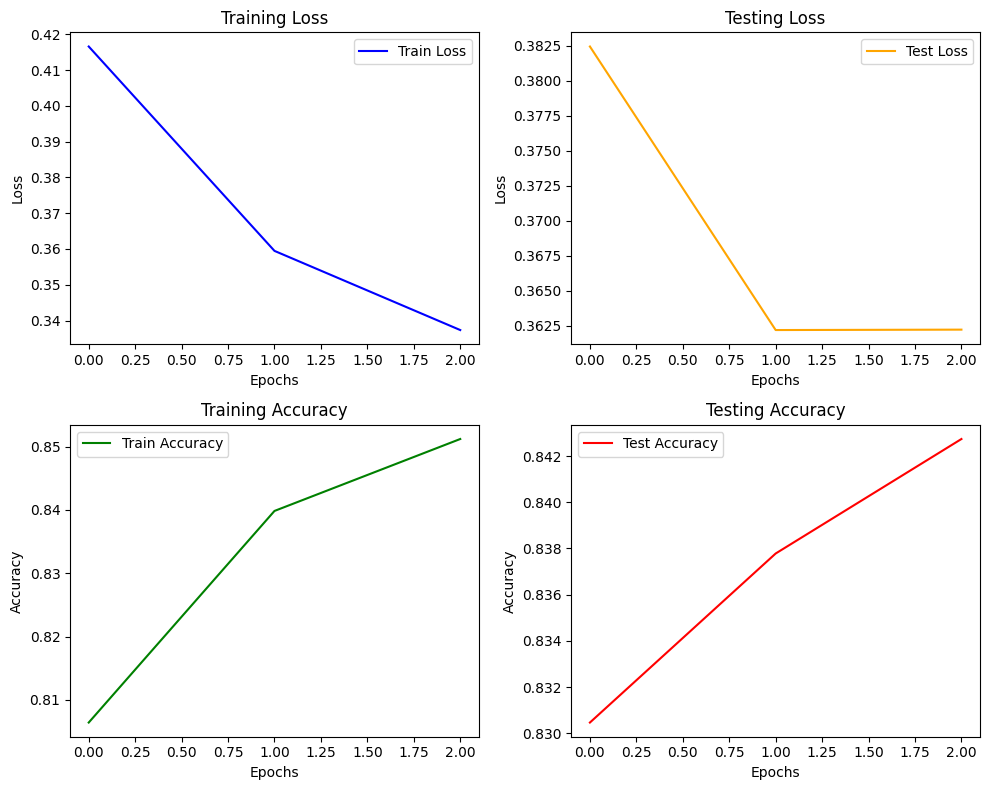

In [ ]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

num_epochs = 3
epochs = list(range(0, num_epochs))

# Create 2x2 grid of subplots using plt.subplot
plt.figure(figsize=(10, 8))

# Training Loss
plt.subplot(2, 2, 1)  # (rows, columns, index)
plt.plot(epochs, train_losses, color='blue', label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Testing Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, test_losses, color='orange', label='Test Loss')
plt.title('Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Training Accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, train_accuracies, color='green', label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Testing Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, test_accuracies, color='red', label='Test Accuracy')
plt.title('Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model2, 'hate_speech_base_model.pth')